# Чекпоинт 2: Моделирование и Эксперименты
В этом ноутбуке мы проводим эксперименты с различными моделями машинного обучения, осуществляем перебор гиперпараметров и применяем метод PCA для снижения размерности. Этот ноутбук является интерактивной версией скриптов `train_models.py` и `run_pca.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Отключаем ворнинги для чистоты вывода
import warnings
warnings.filterwarnings('ignore')

## 1. Уменьшение размерности (PCA)
Поскольку после `OneHotEncoder` количество признаков сильно возрастает (матрица становится разреженной), полезно посмотреть, как данные проецируются на 2D-пространство главных компонент.

Доля объясненной дисперсии (2 компоненты): 0.4244


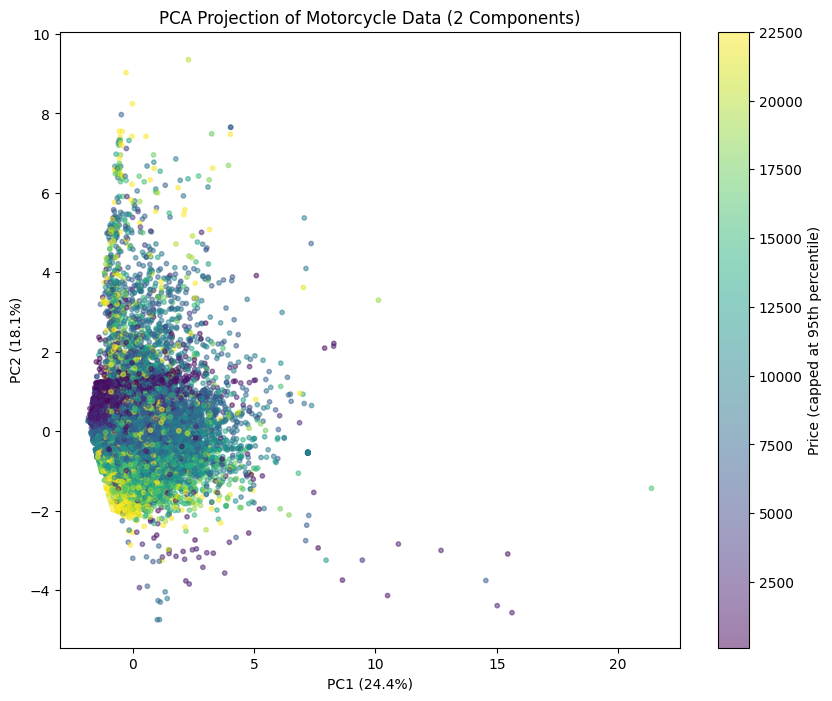

In [2]:
# Загрузка данных
X_train = np.load("../data/processed/X_train_processed.npy")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

# Применяем PCA, оставляем 2 компоненты для визуализации
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

print(f"Доля объясненной дисперсии (2 компоненты): {sum(pca.explained_variance_ratio_):.4f}")

# Визуализация
plt.figure(figsize=(10, 8))
# Для лучшей визуализации ограничим цены (например, до 95-го перцентиля)
price_cap = np.percentile(y_train, 95)

scatter = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=np.clip(y_train, 0, price_cap), 
    cmap='viridis', 
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label='Price (capped at 95th percentile)')
plt.title('PCA Projection of Motorcycle Data (2 Components)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

## 2. Эксперименты с моделями и перебор гиперпараметров
Обучим несколько различных моделей (в том числе градиентный бустинг и случайный лес) и подберем им оптимальные гиперпараметры с помощью `GridSearchCV`.

In [3]:
X_val = np.load("../data/processed/X_val_processed.npy")
y_val = pd.read_csv("../data/processed/y_val.csv").values.ravel()

SEED = 42

models = {
    'Ridge': {
        'model': Ridge(random_state=SEED),
        'params': {'alpha': [0.1, 1.0, 10.0]}
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=SEED, n_jobs=-1),
        'params': {'n_estimators': [50, 100], 'max_depth': [10, 20]}
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=SEED, objective='reg:squarederror', n_jobs=-1),
        'params': {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1], 'max_depth': [5, 7, 9]}
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=-1),
        'params': {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 63, 127]}
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=SEED, verbose=0, thread_count=-1),
        'params': {'iterations': [100, 300], 'learning_rate': [0.05, 0.1], 'depth': [6, 8]}
    }
}

results = []
best_overall_model = None
best_mae = float('inf')
best_model_name = ""

for name, config in models.items():
    print(f"--- Обучение {name} ---")
    start_time = time.time()
    
    grid = GridSearchCV(config['model'], config['params'], cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_val)
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")
    print(f"Время: {time.time() - start_time:.2f} сек\n")
    
    results.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    
    if mae < best_mae:
        best_mae = mae
        best_overall_model = best_model
        best_model_name = name

# Сравнение с бейзлайном
baseline_path = "../report/baseline_results.csv"
results_df = pd.DataFrame(results)

if os.path.exists(baseline_path):
    baseline_df = pd.read_csv(baseline_path)
    baseline_df.rename(columns={'model': 'Model'}, inplace=True)
    baseline_df['Best Params'] = "default"
    results_df = pd.concat([baseline_df, results_df], ignore_index=True)

results_df.sort_values('MAE')

--- Обучение Ridge ---


Лучшие параметры: {'alpha': 0.1}
MAE: 2355.61, RMSE: 4368.34, R2: 0.6184
Время: 7.47 сек

--- Обучение RandomForest ---


Лучшие параметры: {'max_depth': 20, 'n_estimators': 100}
MAE: 2418.79, RMSE: 4398.51, R2: 0.6131
Время: 422.64 сек

--- Обучение XGBoost ---


Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300}
MAE: 2176.93, RMSE: 4146.63, R2: 0.6562
Время: 167.44 сек

--- Обучение LightGBM ---


Лучшие параметры: {'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 63}
MAE: 2197.38, RMSE: 4184.84, R2: 0.6498
Время: 419.59 сек

--- Обучение CatBoost ---


Лучшие параметры: {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}
MAE: 2444.08, RMSE: 4328.30, R2: 0.6254
Время: 10.80 сек



,Model,MAE,RMSE,R2,Best Params
3,XGBoost,2176.932129,4146.626098,0.656158,"{'learning_rate': 0.1, 'max_depth': 9, 'n_esti..."
4,LightGBM,2197.383149,4184.839076,0.649791,"{'learning_rate': 0.05, 'n_estimators': 300, '..."
1,Ridge,2355.605538,4368.335480,0.618406,{'alpha': 0.1}
0,LinearRegression,2356.702051,4379.237219,0.616499,default
2,RandomForest,2418.794374,4398.513287,0.613115,"{'max_depth': 20, 'n_estimators': 100}"
5,CatBoost,2444.084711,4328.303548,0.625368,"{'depth': 8, 'iterations': 300, 'learning_rate..."


## 3. Выводы
Как видно из таблицы, **XGBoost** показывает наилучшие результаты качества (минимальный MAE и RMSE, максимальный R2). Он же выбран в качестве финальной модели для дальнейшего использования.